In [27]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
from math import log, e, pi, sqrt
from statistics import NormalDist
from scipy.stats import norm

In [28]:
N = 2 ** 32
p = 1 - e ** (-2)
alpha = 0.8
t = 5000
cost_Factor = 5

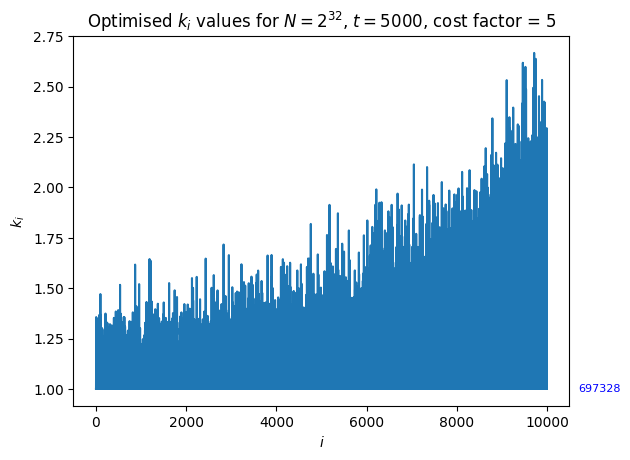

In [29]:
with open('N_32_alpha_0.8.pkl', 'rb') as f:
    result = pickle.load(f)

kjs, m_0, final_cost, m_values = result

# plot kjs
plt.plot(kjs)
plt.xlabel('$i$')
plt.ylabel('$k_i$')

# label mt at the end of the plot, not an arrow, just text
mt = m_values[-1]
y = kjs[-1]

plt.annotate(round(mt),
             xy = (len(kjs)+500, y),   # place text outside box in line with end of curve
             xytext = (6, 0),
             color = 'blue',
             textcoords = 'offset points',
             size=8,
             va='center')

plt.title('Optimised $k_i$ values for $N=2^{32}$, $t=5000$, cost factor = 5')
plt.show()


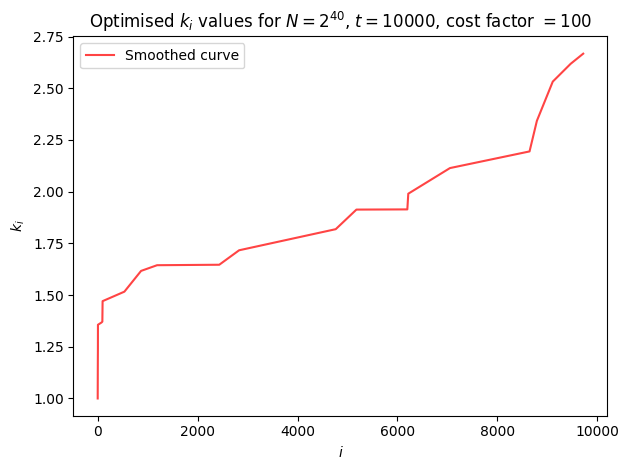

(0, np.float64(1.0000000000000027))
(2, np.float64(1.1448697047241405))
(3, np.float64(1.1997447880421608))
(4, np.float64(1.2327758705595024))
(5, np.float64(1.3564667181906285))
(74, np.float64(1.3671165111535752))
(93, np.float64(1.3713699508127895))
(98, np.float64(1.4706910241537003))
(534, np.float64(1.5165094074407637))
(868, np.float64(1.616918303146499))
(1188, np.float64(1.6444652439909029))
(2433, np.float64(1.6467178312845658))
(2830, np.float64(1.716640286360004))
(4764, np.float64(1.8187063283428027))
(5178, np.float64(1.9134210783851955))
(6197, np.float64(1.9143633306573224))
(6216, np.float64(1.9902652235264806))
(7050, np.float64(2.1141681380863986))
(8643, np.float64(2.1947167971344066))
(8790, np.float64(2.342680254500272))
(9108, np.float64(2.5323782629732583))
(9466, np.float64(2.6184994696929795))
(9717, np.float64(2.6674009236605096))


In [45]:
new_y = kjs.copy()
x_values = [True] * len(new_y)  # True means keep the point, False means remove it

running_max = 0
tol = 20
for i in range(len(new_y)):
    if i == 0:
        running_max = new_y[i]
    else:
        if (new_y[i] >= running_max) & (new_y[i] <= running_max + tol):
            # keep the point
            # but now check if its max, if it is, update the running max
            if new_y[i] > running_max:
                running_max = new_y[i]
        else:
            # remove the point
            x_values[i] = False
            new_y[i] = new_y[i - 1]  # set to previous value to create a flat line until the next valid point


## plot the new curve
# hvae to match the x values to the new y values, so only plot the points where x_values is True
coords = []
for i, val in enumerate(x_values):
    if val:
        coords.append((i, new_y[i]))

plt.plot([x for x, y in coords], [y for x, y in coords], color='#FF4444', label='Smoothed curve')
plt.xlabel('$i$')
plt.ylabel('$k_i$')
plt.legend()
plt.title(r'Optimised $k_i$ values for $N = 2^{40}$, $t = 10000$, cost factor $= 100$')
plt.tight_layout()
plt.show()

for item in coords:
    print(item) 

Fitted power law parameters: a=0.00028035942803233786, b=0.9100620036612727, c=1.2955020653764049
Optimised m_t for t=10000: 697328.1793131833


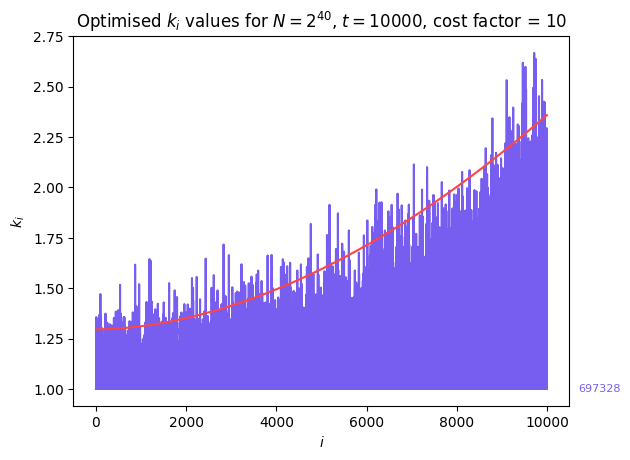

In [90]:
from scipy.optimize import curve_fit

# Separate tuples into X and Y arrays
x_data, y_data = zip(*coords)
x = np.array(x_data)
y = np.array(y_data)

# x_plot = np.linspace(0, 8823, 500)
# plt.figure(figsize=(10, 6))
# plt.scatter(x, y, s=15, color='red', label='Data', zorder=5)

label = "Power law: a*(x+1)^b + c"
def power_law(x, a, b, c):
    return a * (x + 1) ** b + c  # +1 avoids x=0 issues

# Fit the power law model to the data
popt, _ = curve_fit(power_law, x, y, maxfev=10000)
y_pred = power_law(x, *popt)
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot
# print(f"{label}")
# print(f"  Params: {popt}")
# print(f"  R² = {r2:.6f}\n")
# plt.plot(x_plot, power_law(x_plot, *popt), label=f"{label} (R²={r2:.4f})")

# plt.xlabel("i")
# plt.ylabel("k_i")
# plt.title("Curve fits to optimised k_i values")
# plt.legend(fontsize=8)
# plt.ylim(0, 550)
# plt.tight_layout()
# plt.show()


a, b, c = popt
print(f"Fitted power law parameters: a={a}, b={b}, c={c}")

# plot kjs
plt.plot(kjs, color='#785EF0', label='Optimised $k_i$ values')
plt.xlabel('$i$')
plt.ylabel('$k_i$')

# label mt at the end of the plot, not an arrow, just text
mt = m_values[-1]
y = kjs[-1]
print("Optimised m_t for t=10000:", mt)

plt.annotate(round(mt),
             xy = (len(kjs)+500, y),   # place text outside box in line with end of curve
             xytext = (6, 0),
             color = '#785EF0',
             textcoords = 'offset points',
             size=8,
             va='center')

# plot vanilla m_t as a horizontal line at y=1
# vanilla_mt = calculate_vanilla_mt_formula(N, t, alpha)
# print("Vanilla m_t for t=10000:", vanilla_mt)
# plt.axhline(y=1, color='#DC267F', linestyle='--', label='Vanilla cherry-picks')

# annotate vanilla m_t line
# plt.annotate(round(vanilla_mt),
#              xy = (len(kjs)+500, 1),   # place text outside box in line with end of curve
#              xytext = (6, 0),
#              color = '#DC267F',
#              textcoords = 'offset points',
#              size=8,
#              va='center')

# plot the fitted power law curve
x_fit = np.arange(len(kjs))
# adjust third parameter c
# a = 0.00000235828104
# b = 2.05290278
# c = 20.6085624
# a=0.00002735942803233786
# b=1.1399620036612727
# c=1.2955020653764049
# Force a convex "valley" sweep to catch the end spike while dipping in the middle
a = 0.0000000509  # Dropped significantly to keep the right side under 2.75
b = 1.83        # Pushed well above 1.0 to make it convex
c = 1.2955      # Keeps your starting point at i = 0 right around 1.30

popt = [a, b, c]

y_fit = power_law(x_fit, *popt)
plt.plot(x_fit, y_fit, color='#FF4444', label='Fitted power law curve')



plt.title('Optimised $k_i$ values for $N=2^{40}$, $t=10000$, cost factor = 10')
plt.show()

In [177]:
# Choose your inflation factor (e.g., 1.5 means 50% larger y-values)
inflation_factor = 63.94

# Apply the inflation
a_inflated = a * inflation_factor
b_inflated = b                # Shape stays exactly the same
c_inflated = c * inflation_factor

popt_inflated = [a_inflated, b_inflated, c_inflated]

# plot
y_fit_inflated = power_law(x_fit, *popt_inflated)
# plt.plot(x_fit, y_fit_inflated, color='#FF4444', label=f'Inflated power law curve (factor={inflation_factor})')
# plt.ylim(1.0 * inflation_factor, 2.75 * inflation_factor)
# plt.xlabel('$i$')
# plt.ylabel('$k_i$')
# plt.title('Inflated power law curve')
# plt.legend()
# plt.show()

In [178]:
y_rounded = [round(val) for val in y_fit_inflated]

# need to see how much it would cost
# so need approximation here too

def calculate_m0(N, t, alpha):
    mttarget = (2 * N) / (t + 2)
    return (alpha * mttarget) / (1 - alpha)

def get_mean(N, m):
    return N - (N*(1 - 1/N)**m)

def get_std(N, m):
    # E1 and E2
    E1 = (1 - 1 / N) ** m
    E2 = (1 - 2 / N) ** m
    
    sqrt_term = N * (((N - 1) * E2) + E1 - (N * (E1 ** 2)))
    if (sqrt_term < 0):
        return 0
    else:
        return sqrt(sqrt_term)


def approx_mi(N, m, k):
    average = get_mean(N, m)
    sd = get_std(N, m)
    m = average + NormalDist().inv_cdf((k - pi / 8) / (k - pi / 4 + 1)) * sd
    return m

# Table with the approximation of the occupancy problem
def table_approx(N, t, alpha, k_values):
    m0 = round(calculate_m0(N, t, alpha))
    m_values = [m0]
    m = m0

    for i in range(t):
        m = approx_mi(N, m, k_values[i])
        m_values.append(m)

    return m_values

# calculate cost
def calc_cost(m_values, k_values, k_cost):
    total_cost = 0
    for i in range(len(k_values)):
        total_cost += m_values[i] + (m_values[i] * k_values[i] * k_cost)
    return total_cost


# calculate the m values for the inflated curve
N = 2 ** 32
t = 10000
alpha = 0.8
k_cost = 1/20

## calculate wht cost would be if all kis = 100
const_kis = [100] * t
m_values_const_kis = table_approx(N, t, alpha, const_kis)
total_cost_const_kis = calc_cost(m_values_const_kis, const_kis, k_cost)
print("Total cost if all kis = 100:", total_cost_const_kis)


m_values_inflated = table_approx(N, t, alpha, y_rounded)
total_cost_inflated = calc_cost(m_values_inflated, y_rounded, k_cost)
print("Total cost for inflated curve:", total_cost_inflated)

if total_cost_inflated < total_cost_const_kis:
    print("The inflated curve is cheaper than using constant k_i = 100.")
else:
    print("The inflated curve is more expensive than using constant k_i = 100.")

Total cost if all kis = 100: 89029621839.58583
Total cost for inflated curve: 89057807073.38551
The inflated curve is more expensive than using constant k_i = 100.


In [181]:
for item in y_rounded:
    print(item)

# save the rounded inflated curve values to a pkl file
with open('inflated_curve_kis.pkl', 'wb') as f:
    pickle.dump(y_rounded, f)

83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
83
8